In [58]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from utils import * #only needed for xgboost
from friedman1 import *

In [59]:
#Function that returns best params for each pair of (d, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['d', 'seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg.groupby(['d'], group_keys=False).head(k)
    topk_d = topk_df[['d', 'method', 'avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df




In [60]:
# For gaussian errors, we simply combine previous results with LAD results
data_gaussian = pd.read_csv('results/200_gaussian.csv')

# For slash errors
data_slash = pd.read_csv('results/200_slash.csv')
# #data_slash = data_slash[(data_slash['d'] != 10)
#                          & (data_slash['d'] != 9)
#                          & (data_slash['d'] != 8)
#                          & (data_slash['d'] != 7)
#                          & (data_slash['d'] != 6)]

#data_slash = data_slash[data_slash['seed'] != 52]
# For slash errors
data_t= pd.read_csv('results/200_t.csv')
# data_t = data_t[(data_t['d'] != 10) & 
#                 (data_t['d'] != 9)]

# data_t = data_t[data_t['seed'] != 52]

In [61]:

# Here we find the optimal settings
LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
Huber_data_gaussian = data_gaussian[data_gaussian['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_gaussian,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_gaussian,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_gaussian,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
)

#create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])




Text(0, 0.5, 'RMSE')

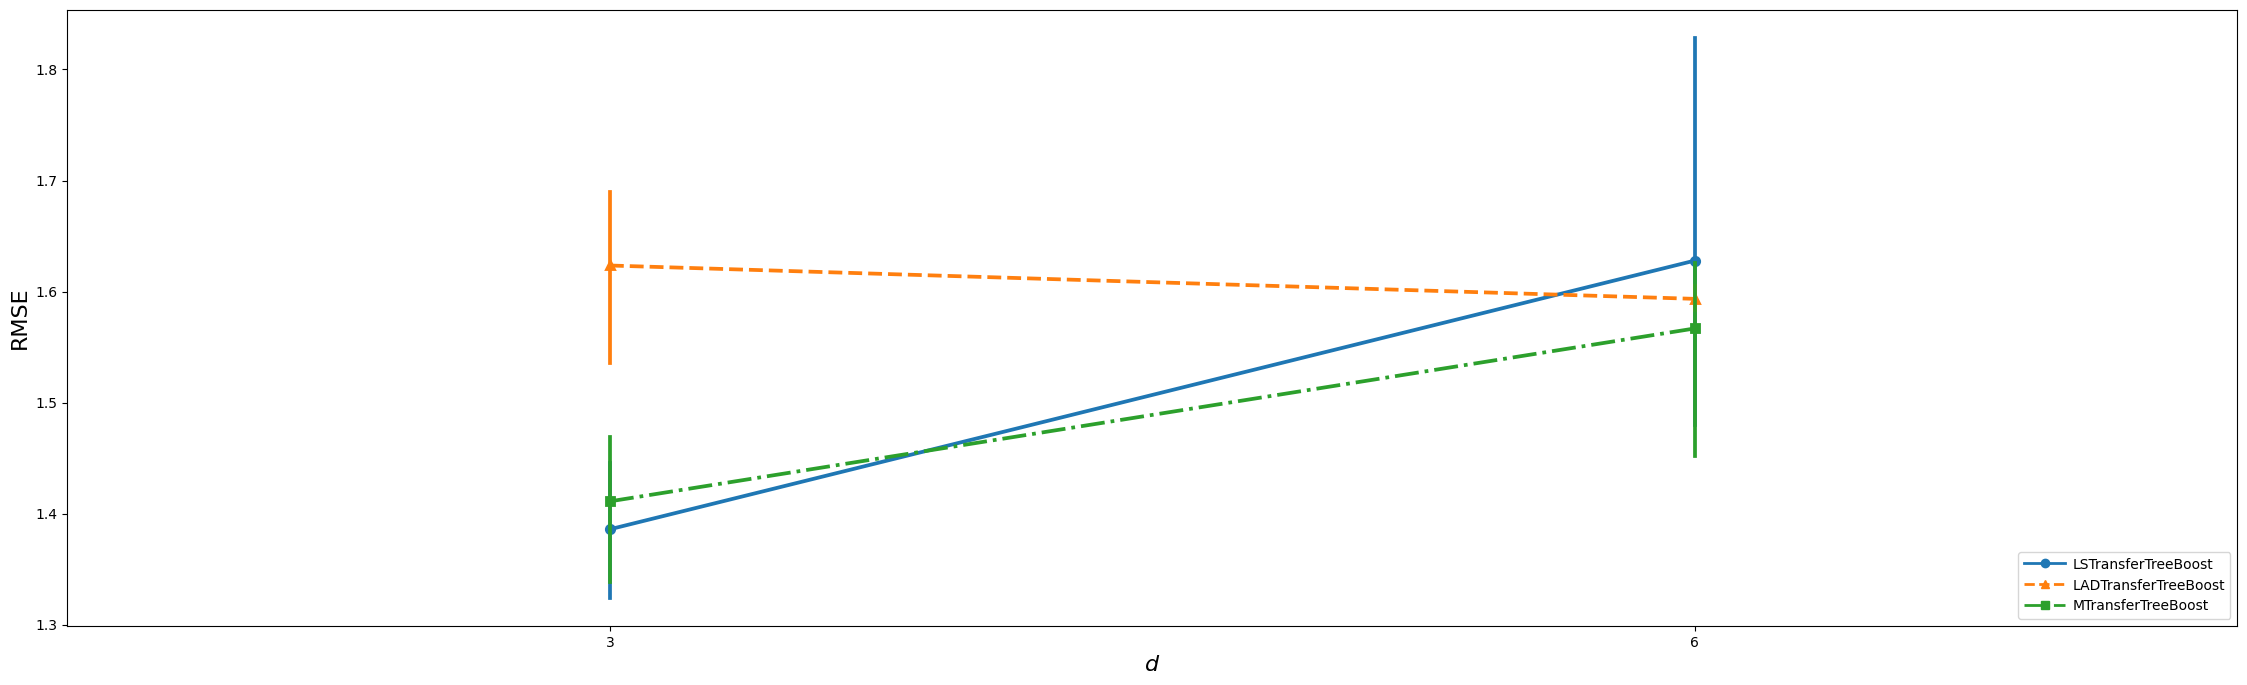

In [62]:
# Plot average test RMSE:s for best hyperparams
from matplotlib.lines import Line2D

plt.figure(figsize = (28,8))
sns.pointplot(data = df, x = 'd', y = 'rmse', hue = 'method', 
                markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])

# grab the current legend
handles, labels = plt.gca().get_legend_handles_labels()

# rebuild legend with longer lines
new_handles = []
for h in handles:
    if isinstance(h, Line2D):
        new_handles.append(Line2D(
            [0], [0], 
            color=h.get_color(),
            linestyle=h.get_linestyle(),
            marker=h.get_marker(),
            markersize=6,
            linewidth=2,
        ))
    else:
        new_handles.append(h)
#plt.legend(loc="lower right")
plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
plt.gca().set_xlabel('$d$', fontsize=16)
plt.gca().set_ylabel('RMSE', fontsize=16)


<Axes: xlabel='d', ylabel='rmse'>

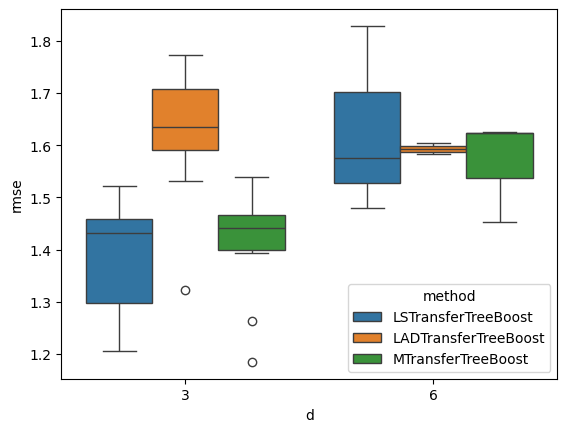

In [63]:
sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

In [64]:
# Here we find the optimal settings
LS_data_slash = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
LAD_data_slash = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
Huber_data_slash = data_slash[data_slash['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_slash,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=6
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_slash,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=6
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_slash,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=6
)

#create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])



Text(0, 0.5, 'RMSE')

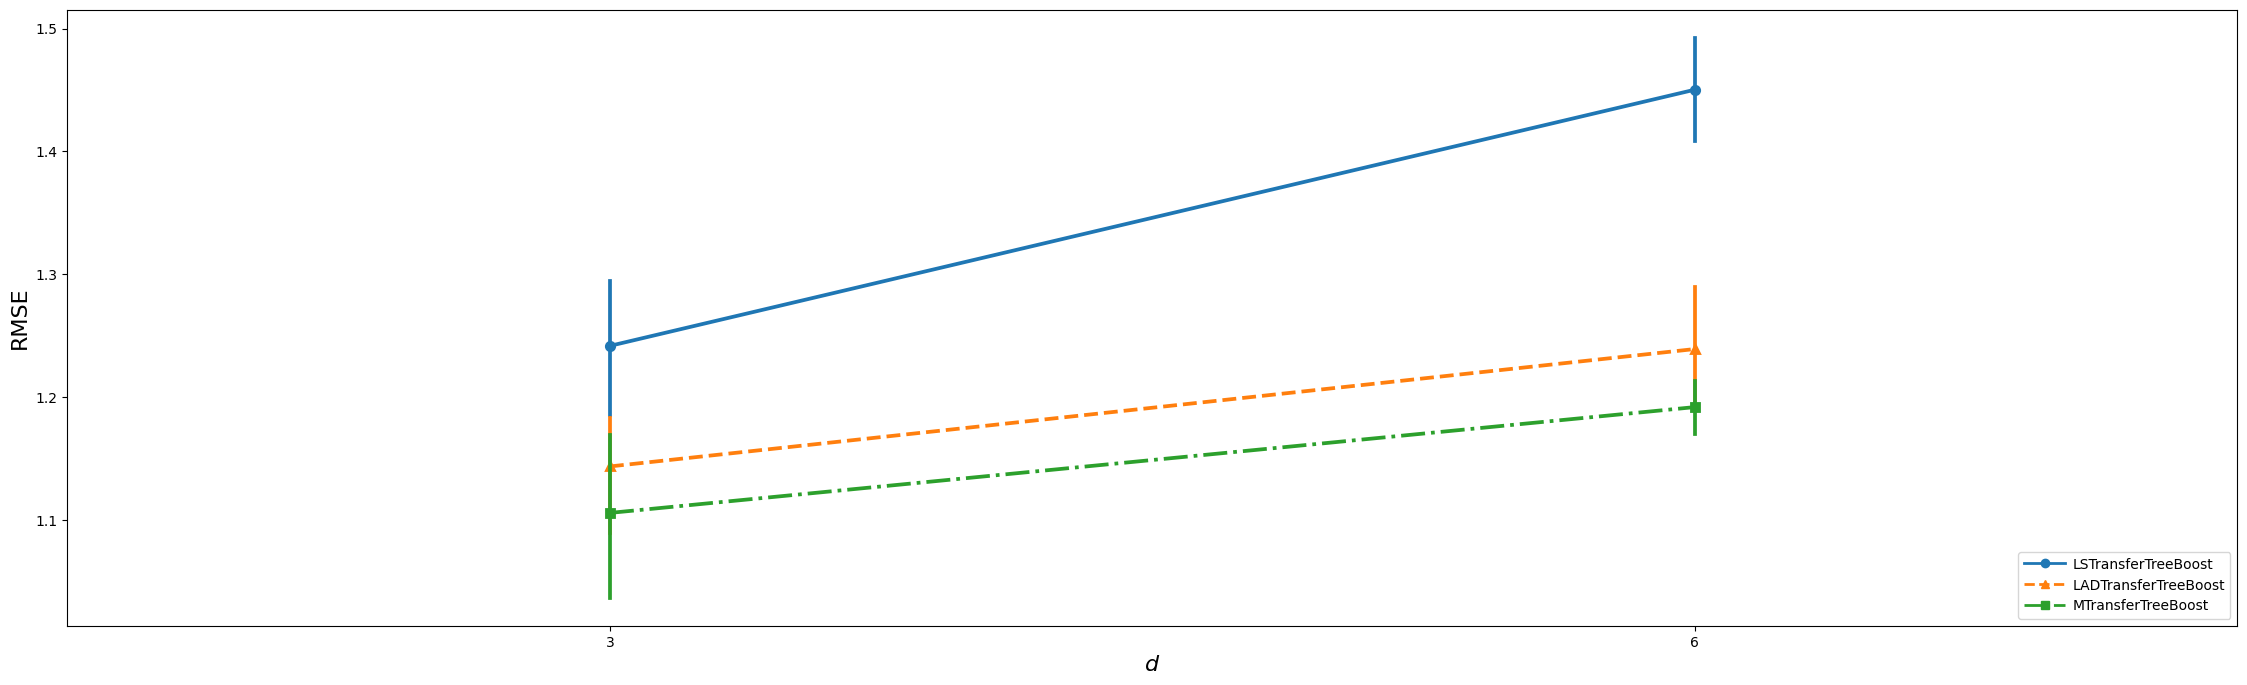

In [65]:
# Plot average test RMSE:s for best hyperparams
from matplotlib.lines import Line2D

plt.figure(figsize = (28,8))
sns.pointplot(data = df, x = 'd', y = 'avg_rmse', hue = 'method', 
                markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])

# grab the current legend
handles, labels = plt.gca().get_legend_handles_labels()

# rebuild legend with longer lines
new_handles = []
for h in handles:
    if isinstance(h, Line2D):
        new_handles.append(Line2D(
            [0], [0], 
            color=h.get_color(),
            linestyle=h.get_linestyle(),
            marker=h.get_marker(),
            markersize=6,
            linewidth=2,
        ))
    else:
        new_handles.append(h)
#plt.legend(loc="lower right")
plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
plt.gca().set_xlabel('$d$', fontsize=16)
plt.gca().set_ylabel('RMSE', fontsize=16)

<Axes: xlabel='d', ylabel='rmse'>

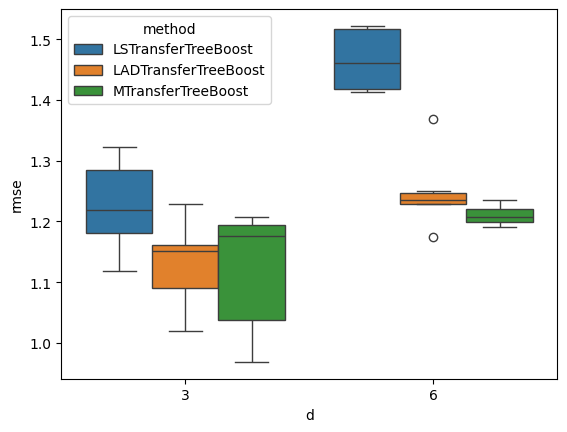

In [66]:
sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

In [67]:
# Here we find the optimal settings
LS_data_t = data_t[data_t['method'] == 'LSTransferTreeBoost']
LAD_data_t = data_t[data_t['method'] == 'LADTransferTreeBoost']
Huber_data_t = data_t[data_t['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_t,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_t,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_t,
['d', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=10
)

#create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])

Text(0, 0.5, 'RMSE')

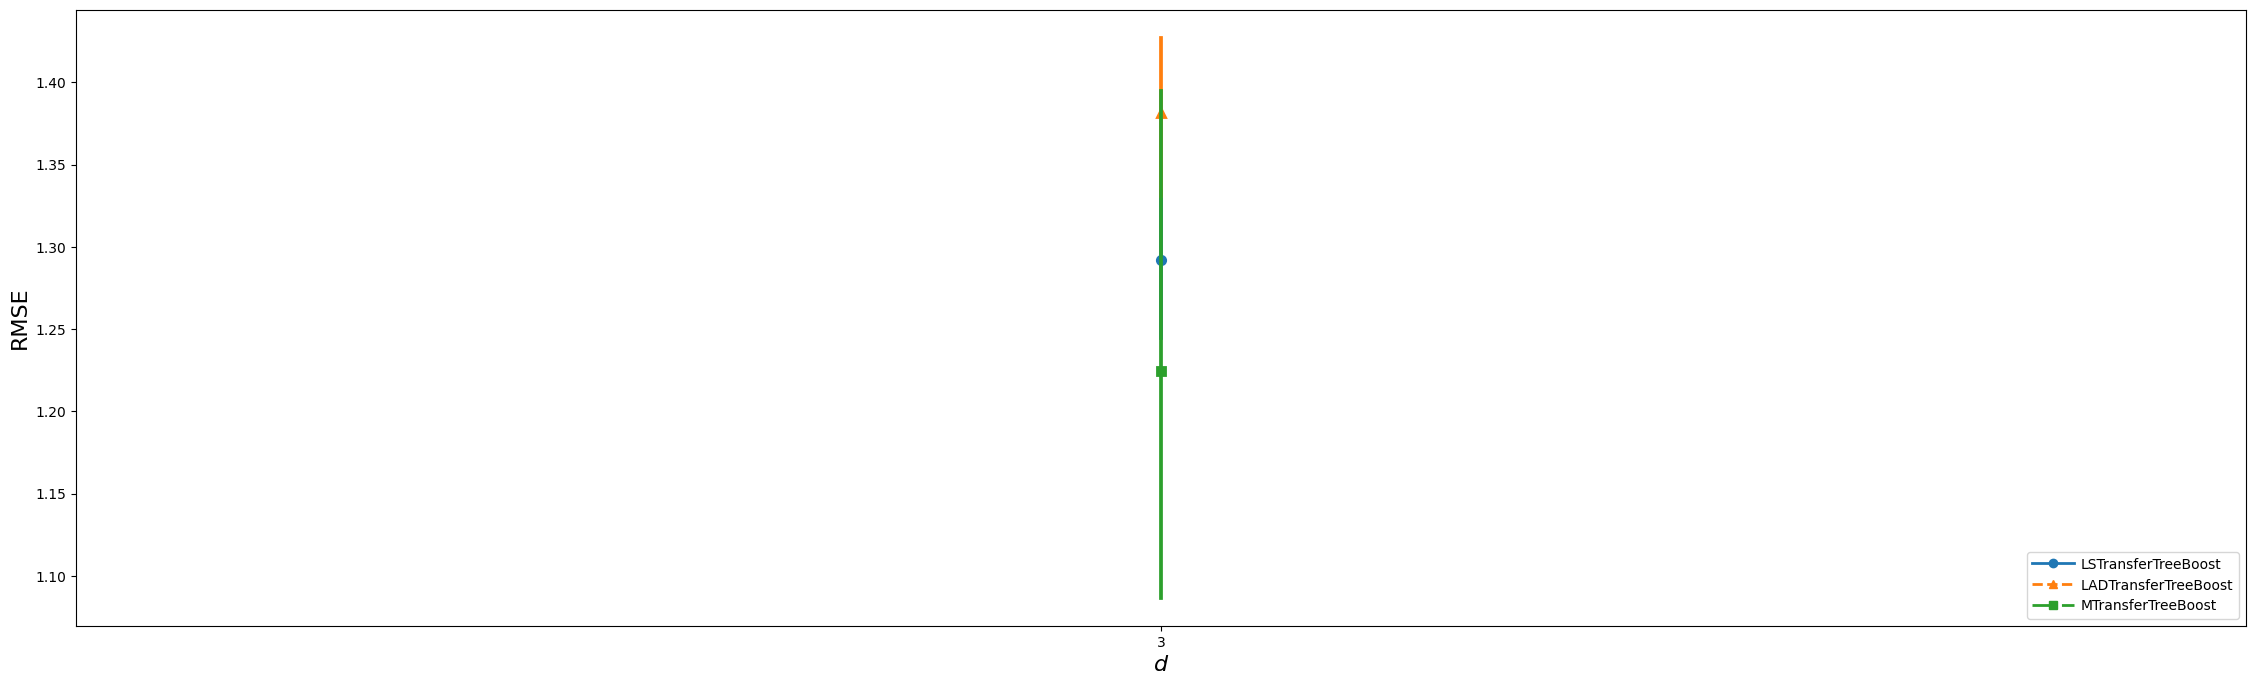

In [68]:
# Plot average test RMSE:s for best hyperparams
from matplotlib.lines import Line2D

plt.figure(figsize = (28,8))
sns.pointplot(data = df, x = 'd', y = 'rmse', hue = 'method', 
                markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])

# grab the current legend
handles, labels = plt.gca().get_legend_handles_labels()

# rebuild legend with longer lines
new_handles = []
for h in handles:
    if isinstance(h, Line2D):
        new_handles.append(Line2D(
            [0], [0], 
            color=h.get_color(),
            linestyle=h.get_linestyle(),
            marker=h.get_marker(),
            markersize=6,
            linewidth=2,
        ))
    else:
        new_handles.append(h)
#plt.legend(loc="lower right")
plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
plt.gca().set_xlabel('$d$', fontsize=16)
plt.gca().set_ylabel('RMSE', fontsize=16)

<Axes: xlabel='d', ylabel='rmse'>

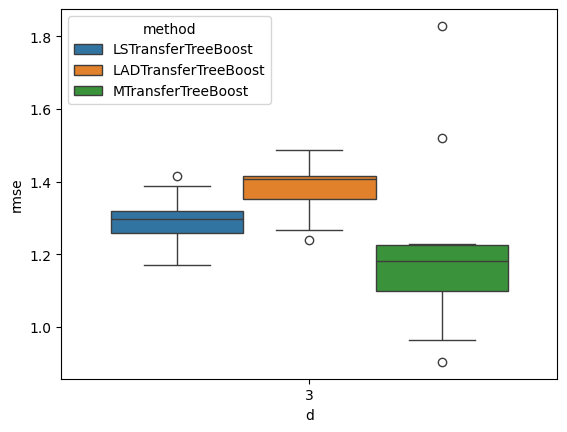

In [69]:
sns.boxplot(data=df, x = 'd', y = 'rmse', hue = 'method')

# Final viz comes here!!!!
data = pd.read_csv('results/200_gaussian_6_optim.csv')
data_slash = pd.read_csv('results/200_slash_6_optim.csv')
# We remove one very weird result. As this did not happen in any other experiment, 
# we believe this is a numerical issue with the code. We remove the seed for both methods.
data = data[data['seed'] != 18] 
data_slash = data_slash[data_slash['seed'] != 18]
data['method'] = data['method'].replace("LSTransferTreeBoost", "LS")
data['method'] = data['method'].replace("LADTransferTreeBoost", "LAD")

data_slash['method'] = data_slash['method'].replace("LSTransferTreeBoost", "LS")
data_slash['method'] = data_slash['method'].replace("LADTransferTreeBoost", "LAD")

plt.figure(figsize = (14,10))

plt.subplot(2,2,1)
sns.boxplot(data = data, x = 'method', y = 'rmse')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('RMSE', fontsize=14)
plt.gca().set_title('Gaussian', fontsize=16)

plt.subplot(2,2,2)
sns.boxplot(data = data, x = 'method', y = 'mae')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('MAE', fontsize=14)
plt.gca().set_title('Gaussian', fontsize=16)

plt.subplot(2,2,3)
sns.boxplot(data = data_slash, x = 'method', y = 'rmse')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('RMSE', fontsize=14)
plt.gca().set_title('Slash', fontsize=16)

plt.subplot(2,2,4)
sns.boxplot(data = data_slash, x = 'method', y = 'mae')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('MAE', fontsize=14)
plt.gca().set_title('Slash', fontsize=16)

plt.savefig('vizes/ls-lad.png', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)







In [70]:
best_Huber_params

,d,v,source_tree_size,target_tree_size,m_0,k,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,method,epochs,val_rmse,val_mae,rmse,mae
8,3,0.075,2,1,0.5,0.01,0.917297,0.719896,1,26,70,MTransferTreeBoost,1000,0.917297,0.719896,0.903658,0.712483
9,3,0.075,2,1,0.9,0.01,0.989007,0.777413,1,29,70,MTransferTreeBoost,1000,0.989007,0.777413,0.964972,0.771309
13,3,0.075,2,2,0.9,0.01,1.093556,0.831094,1,41,70,MTransferTreeBoost,1000,1.093556,0.831094,1.089735,0.837223
12,3,0.075,2,2,0.5,0.01,1.128464,0.859913,1,38,70,MTransferTreeBoost,1000,1.128464,0.859913,1.129085,0.868919
4,3,0.075,1,2,0.5,0.01,1.144102,0.889482,1,14,70,MTransferTreeBoost,1000,1.144102,0.889482,1.151823,0.898665
5,3,0.075,1,2,0.9,0.01,1.204240,0.931990,1,17,70,MTransferTreeBoost,1000,1.204240,0.931990,1.209481,0.920785
1,3,0.075,1,1,0.9,0.01,1.246608,0.972939,1,5,70,MTransferTreeBoost,1000,1.246608,0.972939,1.218194,0.954988
0,3,0.075,1,1,0.5,0.01,1.253889,0.979202,1,2,70,MTransferTreeBoost,1000,1.253889,0.979202,1.228507,0.960480
7,3,0.075,1,2,0.9,0.05,1.526325,1.167274,1,23,70,MTransferTreeBoost,1000,1.526325,1.167274,1.519363,1.185740
14,3,0.075,2,2,0.5,0.05,1.832812,1.407230,1,44,70,MTransferTreeBoost,1000,1.832812,1.407230,1.828501,1.420963
